In [1]:
import pandas as pd
import numpy as np

# Simulating a dirty, uncleaned raw data export
raw_data = {
    'Player_Tag': [' Shadow ', 'shadow', ' Viper_99 ', 'VIPER_99', 'Ghost', ' Ghost', 'Blaze', 'BLAZE '],
    'Match_Date': ['2026-06-01', '06/01/2026', '2026/06/02', '2026-06-03', 'June 4, 2026', '2026-06-05', '06-06-2026', '2026-06-07'],
    'Region': [' EU ', 'europe', 'NA', 'north america', 'EU', ' EU ', 'na', 'Asia'],
    'Damage_Dealt': ['2,400', '2400', '1,850', '-500', 'N/A', '3,100', '1,200', '4,500'], # Notice '-500' and 'N/A'!
    'Eliminations': [12, 12, 8, np.nan, 15, 18, 5, 22]
}

df_raw = pd.DataFrame(raw_data)
print("--- Raw Messy Dataset ---")
print(df_raw)

--- Raw Messy Dataset ---
   Player_Tag    Match_Date         Region Damage_Dealt  Eliminations
0     Shadow     2026-06-01            EU         2,400          12.0
1      shadow    06/01/2026         europe         2400          12.0
2   Viper_99     2026/06/02             NA        1,850           8.0
3    VIPER_99    2026-06-03  north america         -500           NaN
4       Ghost  June 4, 2026             EU          N/A          15.0
5       Ghost    2026-06-05            EU         3,100          18.0
6       Blaze    06-06-2026             na        1,200           5.0
7      BLAZE     2026-06-07           Asia        4,500          22.0


In [2]:
df_raw

,Player_Tag,Match_Date,Region,Damage_Dealt,Eliminations
0,Shadow,2026-06-01,EU,"2,400",12.0
1,shadow,06/01/2026,europe,2400,12.0
2,Viper_99,2026/06/02,NA,"1,850",8.0
3,VIPER_99,2026-06-03,north america,-500,NaN
4,Ghost,"June 4, 2026",EU,N/A,15.0
5,Ghost,2026-06-05,EU,"3,100",18.0
6,Blaze,06-06-2026,na,"1,200",5.0
7,BLAZE,2026-06-07,Asia,"4,500",22.0


In [7]:
df_raw.Player_Tag=df_raw.Player_Tag.str.strip().str.upper()
df_raw.Region=df_raw.Region.str.strip().str.upper().replace({'EUROPE': 'EU', 'NORTH AMERICA': 'NA'})

In [8]:
df_raw

,Player_Tag,Match_Date,Region,Damage_Dealt,Eliminations
0,SHADOW,2026-06-01,EU,"2,400",12.0
1,SHADOW,06/01/2026,EU,2400,12.0
2,VIPER_99,2026/06/02,NA,"1,850",8.0
3,VIPER_99,2026-06-03,NA,-500,NaN
4,GHOST,"June 4, 2026",EU,N/A,15.0
5,GHOST,2026-06-05,EU,"3,100",18.0
6,BLAZE,06-06-2026,NA,"1,200",5.0
7,BLAZE,2026-06-07,ASIA,"4,500",22.0


In [9]:
df_raw.Damage_Dealt=pd.to_numeric(df_raw.Damage_Dealt.str.replace(',',''),errors='coerce')

In [13]:
df_raw.Damage_Dealt.mask(df_raw['Damage_Dealt'] < 0,np.nan,inplace=True)

In [14]:
df_raw

,Player_Tag,Match_Date,Region,Damage_Dealt,Eliminations
0,SHADOW,2026-06-01,EU,2400.0,12.0
1,SHADOW,06/01/2026,EU,2400.0,12.0
2,VIPER_99,2026/06/02,NA,1850.0,8.0
3,VIPER_99,2026-06-03,NA,NaN,NaN
4,GHOST,"June 4, 2026",EU,NaN,15.0
5,GHOST,2026-06-05,EU,3100.0,18.0
6,BLAZE,06-06-2026,NA,1200.0,5.0
7,BLAZE,2026-06-07,ASIA,4500.0,22.0


In [15]:
df_raw.Match_Date=pd.to_datetime(df_raw['Match_Date'], format='mixed')

In [21]:
df_raw.drop_duplicates(inplace=True)

In [26]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 0 to 7
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Player_Tag    7 non-null      object        
 1   Match_Date    7 non-null      datetime64[ns]
 2   Region        7 non-null      object        
 3   Damage_Dealt  5 non-null      float64       
 4   Eliminations  6 non-null      float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 336.0+ bytes


In [27]:
df_raw

,Player_Tag,Match_Date,Region,Damage_Dealt,Eliminations
0,SHADOW,2026-06-01,EU,2400.0,12.0
2,VIPER_99,2026-06-02,NA,1850.0,8.0
3,VIPER_99,2026-06-03,NA,NaN,NaN
4,GHOST,2026-06-04,EU,NaN,15.0
5,GHOST,2026-06-05,EU,3100.0,18.0
6,BLAZE,2026-06-06,NA,1200.0,5.0
7,BLAZE,2026-06-07,ASIA,4500.0,22.0


In [29]:
df_raw[df_raw.isna().any(axis=1)]

,Player_Tag,Match_Date,Region,Damage_Dealt,Eliminations
3,VIPER_99,2026-06-03,NA,NaN,NaN
4,GHOST,2026-06-04,EU,NaN,15.0


In [30]:
df_raw = df_raw.fillna({
    'Damage_Dealt': df_raw['Damage_Dealt'].median(),
    'Eliminations': df_raw['Eliminations'].median()
})


In [34]:
df_raw['Damage_Per_Elim']=(df_raw.Damage_Dealt / df_raw.Eliminations).round(2)

In [35]:
df_raw

,Player_Tag,Match_Date,Region,Damage_Dealt,Eliminations,Damage_Per_Elim
0,SHADOW,2026-06-01,EU,2400.0,12.0,200.00
2,VIPER_99,2026-06-02,NA,1850.0,8.0,231.25
3,VIPER_99,2026-06-03,NA,2400.0,13.5,177.78
4,GHOST,2026-06-04,EU,2400.0,15.0,160.00
5,GHOST,2026-06-05,EU,3100.0,18.0,172.22
6,BLAZE,2026-06-06,NA,1200.0,5.0,240.00
7,BLAZE,2026-06-07,ASIA,4500.0,22.0,204.55


In [39]:
groubed=df_raw.groupby('Region').agg({'Damage_Dealt':'mean','Eliminations':'mean','Damage_Per_Elim':'mean'}).round(1)

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

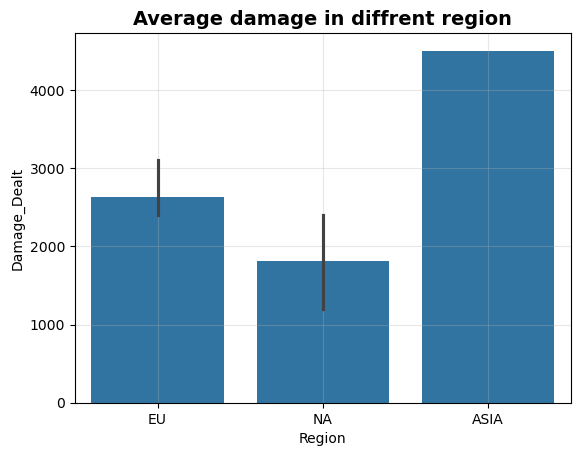

In [46]:
sns.barplot(df_raw,x='Region',y='Damage_Dealt',estimator='mean')
plt.title('Average damage in diffrent region', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()